CONFIDENCE INTERVALS & BOOTSTRAP

sepal length (cm)
  n = 149
  Mean = 5.844
  95% CI: (5.710, 5.977)
  Using z (normal) distribution

sepal width (cm)
  n = 149
  Mean = 3.056
  95% CI: (2.988, 3.125)
  Using z (normal) distribution

petal length (cm)
  n = 149
  Mean = 3.749
  95% CI: (3.465, 4.033)
  Using z (normal) distribution

petal width (cm)
  n = 149
  Mean = 1.195
  95% CI: (1.072, 1.317)
  Using z (normal) distribution

sepal_area
  n = 149
  Mean = 17.818
  95% CI: (17.284, 18.353)
  Using z (normal) distribution

petal_area
  n = 149
  Mean = 5.768
  95% CI: (5.010, 6.525)
  Using z (normal) distribution

sepal length (cm) (Bootstrap)
  Original mean: 5.844
  Bootstrap mean: 5.844
  95% Bootstrap CI: (5.709, 5.978)

sepal width (cm) (Bootstrap)
  Original mean: 3.056
  Bootstrap mean: 3.057
  95% Bootstrap CI: (2.988, 3.123)

petal length (cm) (Bootstrap)
  Original mean: 3.749
  Bootstrap mean: 3.748
  95% Bootstrap CI: (3.464, 4.030)

petal width (cm) (Bootstrap)
  Orig

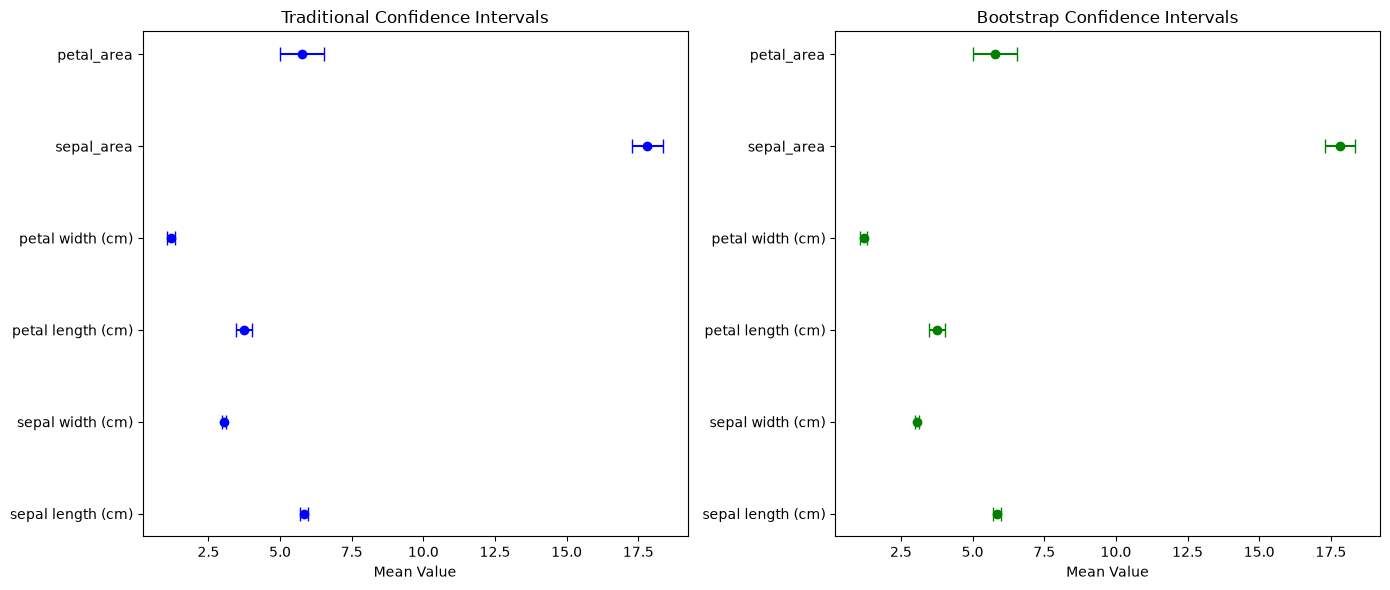


Confidence interval visualizations saved


In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
from scipy import stats
from src.data_loader import DataLoader
import matplotlib.pyplot as plt

# Load cleaned data
loader = DataLoader(data_dir="../data")
df = pd.read_csv(loader.processed_dir / "cleaned_data.csv")

print("=" * 60)
print("CONFIDENCE INTERVALS & BOOTSTRAP")
print("=" * 60)

# ==================== 1. CONFIDENCE INTERVALS ====================

def calculate_confidence_interval(data, confidence=0.95):
    """Calculate confidence interval for mean."""
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    se = std / np.sqrt(n)
    
    if n >= 30:
        z_score = stats.norm.ppf((1 + confidence) / 2)
        margin = z_score * se
        dist = 'z (normal)'
    else:
        t_score = stats.t.ppf((1 + confidence) / 2, df=n-1)
        margin = t_score * se
        dist = "t (Student's)"
    
    return {
        'n': n,
        'mean': mean,
        'std': std,
        'se': se,
        'margin': margin,
        'lower': mean - margin,
        'upper': mean + margin,
        'distribution': dist
    }

# Calculate CIs for all numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
ci_results = {}

for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 0:
        ci_results[col] = calculate_confidence_interval(data)
        
        print(f"\n{col}")
        print(f"  n = {ci_results[col]['n']}")
        print(f"  Mean = {ci_results[col]['mean']:.3f}")
        print(f"  95% CI: ({ci_results[col]['lower']:.3f}, {ci_results[col]['upper']:.3f})")
        print(f"  Using {ci_results[col]['distribution']} distribution")

# ==================== 2. BOOTSTRAP ====================

def bootstrap_ci(data, statistic=np.mean, n_bootstrap=10000, confidence=0.95):
    """Calculate bootstrap confidence interval."""
    n = len(data)
    bootstrap_stats = []
    
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrap_stats.append(statistic(sample))
    
    alpha = 1 - confidence
    lower = np.percentile(bootstrap_stats, alpha/2 * 100)
    upper = np.percentile(bootstrap_stats, (1 - alpha/2) * 100)
    
    return {
        'original': statistic(data),
        'bootstrap_mean': np.mean(bootstrap_stats),
        'bootstrap_std': np.std(bootstrap_stats),
        'lower': lower,
        'upper': upper,
        'confidence': confidence
    }

# Bootstrap for each numeric column
bootstrap_results = {}

for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 0:
        bootstrap_results[col] = bootstrap_ci(data)
        
        print(f"\n{col} (Bootstrap)")
        print(f"  Original mean: {bootstrap_results[col]['original']:.3f}")
        print(f"  Bootstrap mean: {bootstrap_results[col]['bootstrap_mean']:.3f}")
        print(f"  95% Bootstrap CI: ({bootstrap_results[col]['lower']:.3f}, {bootstrap_results[col]['upper']:.3f})")

# ==================== 3. COMPARE CI METHODS ====================

print("\n" + "=" * 60)
print("COMPARISON: Traditional CI vs Bootstrap CI")
print("=" * 60)

comparison_data = []
for col in numeric_cols:
    if col in ci_results and col in bootstrap_results:
        comparison_data.append({
            'column': col,
            'mean': ci_results[col]['mean'],
            'ci_lower': ci_results[col]['lower'],
            'ci_upper': ci_results[col]['upper'],
            'bootstrap_lower': bootstrap_results[col]['lower'],
            'bootstrap_upper': bootstrap_results[col]['upper'],
            'ci_width': ci_results[col]['upper'] - ci_results[col]['lower'],
            'bootstrap_width': bootstrap_results[col]['upper'] - bootstrap_results[col]['lower']
        })

comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv('../reports/ci_comparison.csv', index=False)

print("\nConfidence interval results saved to 'reports/ci_comparison.csv'")

# ================= 4. VISUALIZE CONFIDENCE INTERVALS =================

def plot_confidence_intervals(ci_results, bootstrap_results):
    """Plot confidence intervals for all numeric columns."""
    cols = list(ci_results.keys())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    for i, col in enumerate(cols):
        ci = ci_results[col]
        ax1.errorbar(ci['mean'], i,
                    xerr=ci['margin'],
                    fmt='o', capsize=5, color='blue')
    ax1.set_yticks(range(len(cols)))
    ax1.set_yticklabels(cols)
    ax1.set_xlabel('Mean Value')
    ax1.set_title('Traditional Confidence Intervals')
    
    for i, col in enumerate(cols):
        if col in bootstrap_results:
            boot = bootstrap_results[col]
            ax2.errorbar(boot['original'], i,
                        xerr=[[boot['original'] - boot['lower']],
                              [boot['upper'] - boot['original']]],
                        fmt='o', capsize=5, color='green')
    ax2.set_yticks(range(len(cols)))
    ax2.set_yticklabels(cols)
    ax2.set_xlabel('Mean Value')
    ax2.set_title('Bootstrap Confidence Intervals')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/confidence_intervals_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot CIs
if ci_results and bootstrap_results:
    plot_confidence_intervals(ci_results, bootstrap_results)

print("\nConfidence interval visualizations saved")